In [29]:
import math
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
warnings.filterwarnings('ignore')

In [5]:
matches = pd.read_csv('data/club-rankings-ext/Matches.csv')

In [6]:
matches.shape

(230557, 48)

In [7]:
matches.head()

,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,FTHome,FTAway,FTResult,HTHome,HTAway,HTResult,HomeShots,AwayShots,HomeTarget,AwayTarget,HomeFouls,AwayFouls,HomeCorners,AwayCorners,HomeYellow,AwayYellow,HomeRed,AwayRed,OddHome,OddDraw,OddAway,MaxHome,MaxDraw,MaxAway,Over25,Under25,MaxOver25,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
0,F1,2000-07-28,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,0.0,3.0,1.0,H,2.0,1.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.65,3.3,4.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,0.0,3.0,1.0,H,1.0,1.0,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.60,3.4,4.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F2,2000-07-28,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,0.0,0.0,1.0,A,0.0,1.0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F1,2000-07-29,NaN,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,0.0,0.0,0.0,1.0,A,0.0,1.0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.70,3.3,3.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F1,2000-07-29,NaN,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,0.0,0.0,1.0,1.0,D,1.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.65,3.3,4.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
clubelo_club_rankings = pd.read_csv('data/club-rankings-ext/clubelo-club-rankings.csv')

In [9]:
clubelo_club_rankings.shape

(550409, 9)

In [10]:
clubelo_club_rankings.head()

,Rank,Club,Country,Level,Elo,From,To,date,updated_at
0,1.0,Man City,ENG,1,2044.658447,2023-03-17,2023-04-01,2023-04-16,2023-04-16 18:17:58
1,2.0,Bayern,GER,1,1978.942505,2023-03-20,2023-04-01,2023-04-16,2023-04-16 18:17:58
2,3.0,Napoli,ITA,1,1959.318848,2023-03-20,2023-04-02,2023-04-16,2023-04-16 18:17:58
3,4.0,Arsenal,ENG,1,1953.111694,2023-03-20,2023-04-01,2023-04-16,2023-04-16 18:17:58
4,5.0,Real Madrid,ESP,1,1938.318726,2023-03-20,2023-04-02,2023-04-16,2023-04-16 18:17:58


In [11]:
elo_ratings = pd.read_csv('data/club-rankings-ext/EloRatings.csv')

In [12]:
elo_ratings.shape

(245033, 4)

In [13]:
elo_ratings.head()

,date,club,country,elo
0,2000-07-01,Aachen,GER,1453.60
1,2000-07-01,Aalborg,DEN,1482.61
2,2000-07-01,Aalst,BEL,1337.53
3,2000-07-01,Aarhus,DEN,1381.46
4,2000-07-01,Aberdeen,SCO,1360.43


In [14]:
opta_club_rankings = pd.read_csv('data/club-rankings-ext/opta-club-rankings.csv')

In [15]:
opta_club_rankings.shape

(1782000, 8)

In [16]:
opta_club_rankings.head()

,x,rank,team,rating,ranking change 7 days,id,date,updated_at
0,NaN,1.0,Manchester City,100.0,0.0,a3nyxabgsqlnqfkeg41m6tnpp,2024-02-20,2024-02-20 10:09:22
1,NaN,2.0,Real Madrid,97.6,0.0,3kq9cckrnlogidldtdie2fkbl,2024-02-20,2024-02-20 10:09:22
2,NaN,3.0,Internazionale,97.5,0.0,3vo5mpj7catp66nrwwqiuhuup,2024-02-20,2024-02-20 10:09:22
3,NaN,4.0,Liverpool,96.3,0.0,c8h9bw1l82s06h77xxrelzhur,2024-02-20,2024-02-20 10:09:22
4,NaN,5.0,Arsenal,95.5,1.0,4dsgumo7d4zupm2ugsvm4zm4d,2024-02-20,2024-02-20 10:09:22


In [17]:
compared_rankings = pd.read_csv('data/club-rankings-ext/compared-rankings.csv')

In [18]:
compared_rankings.shape

(216624, 9)

In [19]:
compared_rankings.head()

,date,country,id_opta,team_opta,team_clubelo,rating_opta,rating_clubelo,rank_opta,rank_clubelo
0,2024-02-20,ARG,7tev5pifn8hdy4vlts0coha1b,Argentinos Juniors,NaN,75.1,NaN,347.0,NaN
1,2024-02-21,ARG,7tev5pifn8hdy4vlts0coha1b,Argentinos Juniors,NaN,75.4,NaN,323.0,NaN
2,2024-02-22,ARG,7tev5pifn8hdy4vlts0coha1b,Argentinos Juniors,NaN,75.3,NaN,328.0,NaN
3,2024-02-23,ARG,7tev5pifn8hdy4vlts0coha1b,Argentinos Juniors,NaN,75.3,NaN,328.0,NaN
4,2024-02-24,ARG,7tev5pifn8hdy4vlts0coha1b,Argentinos Juniors,NaN,75.3,NaN,328.0,NaN


In [20]:
compared_rankings = compared_rankings[['date', 'team_clubelo', 'rating_opta', 'rating_clubelo']]
compared_rankings.dropna(inplace=True)
compared_rankings.shape

(116708, 4)

In [21]:
compared_rankings.sort_values(by='rating_opta', inplace=True, ascending=False)
compared_rankings.head()

,date,team_clubelo,rating_opta,rating_clubelo
110141,2024-11-24,Inter,100.0,1971.822266
23156,2025-03-11,Liverpool,100.0,2018.310425
23206,2024-03-13,Man City,100.0,2044.850708
23207,2024-03-14,Man City,100.0,2044.850708
23208,2024-03-15,Man City,100.0,2052.299072


In [22]:
compared_rankings['rounded_rating_opta'] = compared_rankings['rating_opta'].round()
compared_rankings['rounded_rating_opta'].value_counts().sort_index()

rounded_rating_opta
61.0        1
62.0       46
63.0      197
64.0      339
65.0      306
66.0      718
67.0      669
68.0     1174
69.0     1503
70.0     2868
71.0     3372
72.0     6446
73.0     5689
74.0     7703
75.0     6272
76.0     7827
77.0     6044
78.0     7940
79.0     5976
80.0     6798
81.0     4795
82.0     5508
83.0     4441
84.0     4718
85.0     3691
86.0     4007
87.0     2158
88.0     2875
89.0     2616
90.0     2717
91.0     1473
92.0     1284
93.0      864
94.0      903
95.0      676
96.0      607
97.0      395
98.0      459
99.0      231
100.0     402
Name: count, dtype: int64

In [23]:
naive_regression = LinearRegression()
X = compared_rankings[['rating_opta']]
y = compared_rankings['rating_clubelo']
naive_regression.fit(X, y)
naive_regression.coef_, naive_regression.intercept_

(array([22.7525255]), np.float64(-266.6101495457251))

In [24]:
naive_regression.score(X, y)

0.9296384310025894

In [78]:
def create_gaussian_subset(df, column_name, target_mean=75, target_std=5, sample_size=10000, random_state=42):
    """
    Create a subset of dataframe that follows a normal distribution
    using acceptance-rejection sampling with Gaussian weights.
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe
    column_name : str
        Column to apply Gaussian weighting to
    target_mean : float
        Desired mean of the distribution
    target_std : float
        Desired standard deviation
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    DataFrame : Subset following approximate normal distribution
    """
    np.random.seed(random_state)
    
    # Calculate Gaussian weights for each row
    values = df[column_name].values
    weights = np.exp(-0.5 * ((values - target_mean) / target_std) ** 2)
    
    # Normalize weights to probabilities
    probabilities = weights / weights.sum()
    
    sampled_indices = np.random.choice(
        df.index, 
        size=sample_size, 
        replace=True,  # Allow replacement to get proper distribution
        p=probabilities
    )
    
    # Create subset
    subset = df.loc[sampled_indices].copy()
    
    return subset

# Create Gaussian-weighted subset centered at 75 with std 5
gaussian_subset = create_gaussian_subset(
    compared_rankings, 
    'rating_opta', 
    target_mean=75, 
    target_std=5, 
    sample_size=1000,
)

print(f"Original size: {len(compared_rankings)}")
print(f"Subset size: {len(gaussian_subset)}")
print(f"\nOriginal rating_opta stats:")
print(f"  Mean: {compared_rankings['rating_opta'].mean():.2f}")
print(f"  Std: {compared_rankings['rating_opta'].std():.2f}")
print(f"\nSubset rating_opta stats:")
print(f"  Mean: {gaussian_subset['rating_opta'].mean():.2f}")
print(f"  Std: {gaussian_subset['rating_opta'].std():.2f}")

Original size: 116708
Subset size: 1000

Original rating_opta stats:
  Mean: 79.31
  Std: 6.75

Subset rating_opta stats:
  Mean: 76.22
  Std: 3.69


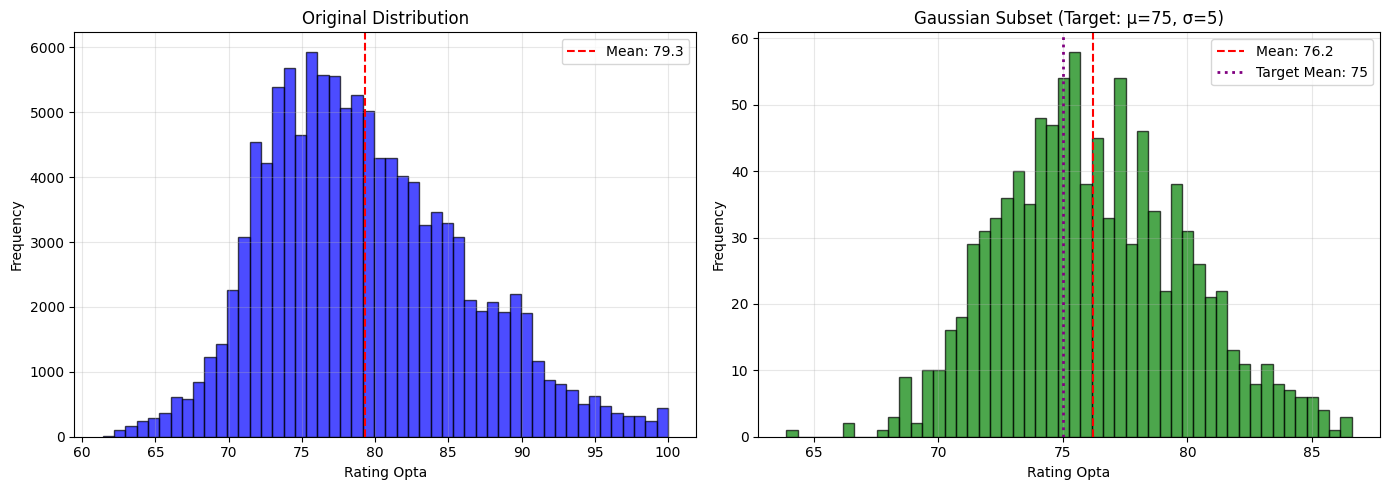

In [79]:
# Visualize the distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
axes[0].hist(compared_rankings['rating_opta'], bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(compared_rankings['rating_opta'].mean(), color='red', linestyle='--', 
                label=f'Mean: {compared_rankings["rating_opta"].mean():.1f}')
axes[0].set_xlabel('Rating Opta')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gaussian subset distribution
axes[1].hist(gaussian_subset['rating_opta'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(gaussian_subset['rating_opta'].mean(), color='red', linestyle='--', 
                label=f'Mean: {gaussian_subset["rating_opta"].mean():.1f}')
axes[1].axvline(75, color='purple', linestyle=':', linewidth=2,
                label='Target Mean: 75')
axes[1].set_xlabel('Rating Opta')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Gaussian Subset (Target: μ=75, σ=5)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Use Gaussian Subset for Regression

Now fit the regression on the Gaussian-weighted subset to get better predictions for teams rated around 75.

In [80]:
# Fit regression on Gaussian subset
gaussian_regression = LinearRegression()
X_gaussian = gaussian_subset[['rating_opta']]
y_gaussian = gaussian_subset['rating_clubelo']
gaussian_regression.fit(X_gaussian, y_gaussian)

print("Naive Regression (all data):")
print(f"  Coefficient: {naive_regression.coef_[0]:.4f}")
print(f"  Intercept: {naive_regression.intercept_:.4f}")
print(f"  R²: {naive_regression.score(X, y):.4f}")

print("\nGaussian Regression (μ=75, σ=5):")
print(f"  Coefficient: {gaussian_regression.coef_[0]:.4f}")
print(f"  Intercept: {gaussian_regression.intercept_:.4f}")
print(f"  R² (on subset): {gaussian_regression.score(X_gaussian, y_gaussian):.4f}")
print(f"  R² (on full data): {gaussian_regression.score(X, y):.4f}")

Naive Regression (all data):
  Coefficient: 22.7525
  Intercept: -266.6101
  R²: 0.9296

Gaussian Regression (μ=75, σ=5):
  Coefficient: 22.5801
  Intercept: -256.9035
  R² (on subset): 0.7863
  R² (on full data): 0.9290
  R² (on subset): 0.7863
  R² (on full data): 0.9290


In [62]:
# Compare predictions for teams rated around 75
test_ratings = np.array([[70], [75], [80], [85]])

print("\nPredictions comparison for different ratings:")
print(f"{'Rating':<10} {'Naive':<15} {'Gaussian':<15} {'Difference':<10}")
print("-" * 50)
for rating in test_ratings:
    pred_naive = naive_regression.predict(rating.reshape(1, -1))[0]
    pred_gaussian = gaussian_regression.predict(rating.reshape(1, -1))[0]
    diff = pred_gaussian - pred_naive
    print(f"{rating[0]:<10} {pred_naive:<15.2f} {pred_gaussian:<15.2f} {diff:<10.2f}")


Predictions comparison for different ratings:
Rating     Naive           Gaussian        Difference
--------------------------------------------------
70         1326.07         1324.35         -1.71     
75         1439.83         1436.01         -3.82     
80         1553.59         1547.67         -5.92     
85         1667.35         1659.33         -8.02     


In [63]:
# compared_rankings['predicted_elo'] = naive_regression.predict(X)
compared_rankings['predicted_elo'] = gaussian_regression.predict(X)

In [64]:
compared_rankings.head()

,date,team_clubelo,rating_opta,rating_clubelo,rounded_rating_opta,predicted_elo,predicted_elo_gaussian
110141,2024-11-24,Inter,100.0,1971.822266,100.0,1994.308894,1994.308894
23156,2025-03-11,Liverpool,100.0,2018.310425,100.0,1994.308894,1994.308894
23206,2024-03-13,Man City,100.0,2044.850708,100.0,1994.308894,1994.308894
23207,2024-03-14,Man City,100.0,2044.850708,100.0,1994.308894,1994.308894
23208,2024-03-15,Man City,100.0,2052.299072,100.0,1994.308894,1994.308894


In [65]:
matches_with_opta_rankings = matches.merge(compared_rankings, left_on=['MatchDate', 'HomeTeam'],
                                          right_on=['date', 'team_clubelo'], how='inner')
matches_with_opta_rankings = matches_with_opta_rankings[['Division', 'MatchDate', 'HomeTeam', 'AwayTeam', 'HomeElo', 'AwayElo', 'FTResult', 'predicted_elo']]

In [66]:
print(matches_with_opta_rankings.shape)
matches_with_opta_rankings.head()

(4751, 8)


,Division,MatchDate,HomeTeam,AwayTeam,HomeElo,AwayElo,FTResult,predicted_elo
0,E0,2024-02-20,Man City,Brentford,2053.20,1751.81,H,1994.308894
1,E1,2024-02-20,Cardiff,Blackburn,1444.10,1445.23,D,1413.680687
2,E1,2024-02-20,Southampton,Hull,1636.46,1497.82,A,1594.568705
3,E0,2024-02-21,Liverpool,Luton,1948.84,1621.88,H,1911.681034
4,I1,2024-02-22,Torino,Lazio,1708.64,1774.58,A,1674.963380


In [67]:
matches_with_opta_rankings.rename(columns={'predicted_elo': 'predicted_elo_home'}, inplace=True)

In [68]:
matches_with_opta_rankings = matches_with_opta_rankings.merge(compared_rankings, left_on=['MatchDate', 'AwayTeam'],
                                          right_on=['date', 'team_clubelo'], how='inner')

In [69]:
print(matches_with_opta_rankings.shape)
matches_with_opta_rankings.head()

(3505, 15)


,Division,MatchDate,HomeTeam,AwayTeam,HomeElo,AwayElo,FTResult,predicted_elo_home,date,team_clubelo,rating_opta,rating_clubelo,rounded_rating_opta,predicted_elo,predicted_elo_gaussian
0,E0,2024-02-20,Man City,Brentford,2053.20,1751.81,H,1994.308894,2024-02-20,Brentford,86.4,1744.053345,86.0,1690.595678,1690.595678
1,E1,2024-02-20,Cardiff,Blackburn,1444.10,1445.23,D,1413.680687,2024-02-20,Blackburn,74.7,1447.900879,75.0,1429.312985,1429.312985
2,E1,2024-02-20,Southampton,Hull,1636.46,1497.82,A,1594.568705,2024-02-20,Hull,77.1,1506.353027,77.0,1482.909435,1482.909435
3,E0,2024-02-21,Liverpool,Luton,1948.84,1621.88,H,1911.681034,2024-02-21,Luton,82.3,1617.433716,82.0,1599.035076,1599.035076
4,I1,2024-02-22,Torino,Lazio,1708.64,1774.58,A,1674.963380,2024-02-22,Lazio,88.6,1767.107544,89.0,1739.725757,1739.725757


In [70]:
matches_with_opta_rankings.rename(columns={'predicted_elo': 'predicted_elo_away'}, inplace=True)

In [71]:
matches_with_opta_rankings.drop(columns=['date', 'team_clubelo', 'rounded_rating_opta', 'rating_clubelo'], inplace=True)

In [72]:
matches_with_opta_rankings['predicted_elo_home'] = matches_with_opta_rankings['predicted_elo_home'].apply(lambda x: round(x, 2))
matches_with_opta_rankings['predicted_elo_away'] = matches_with_opta_rankings['predicted_elo_away'].apply(lambda x: round(x, 2))

In [73]:
matches_with_opta_rankings.head()

,Division,MatchDate,HomeTeam,AwayTeam,HomeElo,AwayElo,FTResult,predicted_elo_home,rating_opta,predicted_elo_away,predicted_elo_gaussian
0,E0,2024-02-20,Man City,Brentford,2053.20,1751.81,H,1994.31,86.4,1690.60,1690.595678
1,E1,2024-02-20,Cardiff,Blackburn,1444.10,1445.23,D,1413.68,74.7,1429.31,1429.312985
2,E1,2024-02-20,Southampton,Hull,1636.46,1497.82,A,1594.57,77.1,1482.91,1482.909435
3,E0,2024-02-21,Liverpool,Luton,1948.84,1621.88,H,1911.68,82.3,1599.04,1599.035076
4,I1,2024-02-22,Torino,Lazio,1708.64,1774.58,A,1674.96,88.6,1739.73,1739.725757


In [75]:
matches_with_opta_rankings.to_csv('data/club-rankings-ext/matches-with-opta-rankings_v2.csv', index=False)